**Libraries and Environmental Values**

In [2]:
%%capture
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Define essential variables for defining model and its properties ...

num_classes = 10 
num_features = 784 #The number of pixels which are considered as features -> 28*28
learning_rate = 0.001
training_steps = 3000
batch_size = 250
display_step = 100
n_hidden = 512

**Dataset loading - MNIST**

In [4]:
(x_train, y_train) , (x_test, y_test) = mnist.load_data()

#Convert the data to Float32
x_train, x_test = np.array(x_train , np.float32), np.array(x_test , np.float32)

#We should flatten the image a a vector with 784 features (pixels)
x_train, x_test = x_train.reshape([-1 , num_features ]), x_test.reshape([-1 , num_features ])

#normalization section -> better and faster training for model
x_train, x_test = x_train/255. , x_test/255.

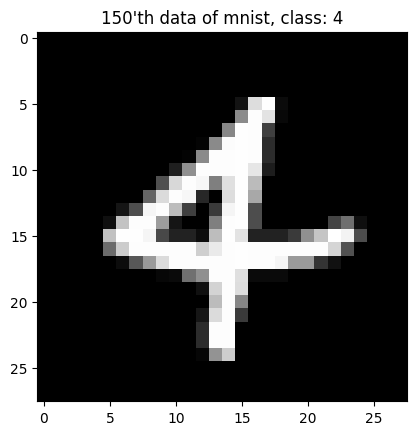

In [5]:
#Demonstrate 150'th number stored in our database
index = 150
label = y_train[index]

image = x_train[index].reshape([28,28])

plt.imshow(image , cmap='gray'); plt.title(f"{index}'th data of mnist, class: {label}"); plt.show()


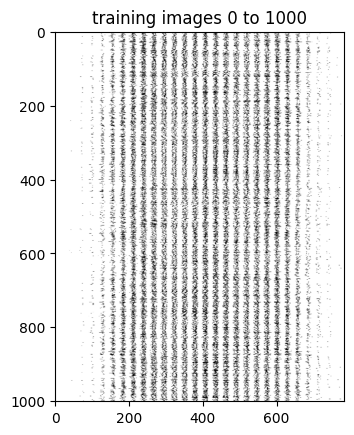

In [6]:
#Demonstrate train section of dataset
images = x_train[0].reshape([1,784])

for index in range(0, 1000):
    images = np.concatenate((images ,  x_train[index].reshape([1,784])))

plt.imshow(images , cmap='gray_r'); plt.title(f"training images 0 to 1000"); plt.show()


In [7]:
train_data = tf.data.Dataset.from_tensor_slices((x_train , y_train))

train_data = train_data.repeat()\
    .shuffle(60000)\
    .batch(batch_size)\
    .prefetch(1)

##Define Network and Optimizer from the scratch

In [8]:
#Build a random value for initiating our NN weights
random_normal = tf.random_normal_initializer()

In [9]:
weights = {
    'h': tf.Variable(random_normal([num_features, n_hidden])),
    'out': tf.Variable(random_normal([n_hidden, num_classes]))
}

biases = {
    'b': tf.Variable(tf.zeros([n_hidden])),
    'out': tf.Variable(tf.zeros([num_classes]))
}

In [ ]:
# Create model.
def neural_net(inputData):
    '''
    A simple 2-layer fully connected neural network.
    Topology:  
        Input Layer: num_features (784 for MNIST)
        Hidden Layer: 512 neurons with Sigmoid activation -> Sigmoid(Input Layer * Weights + Bias)
        Output Layer: num_classes (10 for MNIST) with Softmax activation
    Args:   
        inputData: The input data to the neural network.
    Returns:
        The output of the neural network after applying softmax.
    '''
    
    # Hidden fully connected layer with 512 neurons.
    hidden_layer = tf.add(tf.matmul(inputData, weights['h']), biases['b'])
    # Apply sigmoid to hidden layer output for non-linearity.
    hidden_layer = tf.nn.sigmoid(hidden_layer)

    # Output fully connected layer with a neuron for each class.
    out_layer = tf.matmul(hidden_layer, weights['out']) + biases['out']
    # Apply softmax to normalize the logits to a probability distribution.
    return tf.nn.softmax(out_layer)


In [11]:
def cross_entropy(y_pred, y_true):
    ''' Compute cross-entropy loss.
    Args:   
        y_pred: Predicted output of the neural network (probabilities).
        y_true: True labels (as integers).
    Returns:
        Cross-entropy loss value.
    '''
    # Encode label to a one hot vector.
    y_true = tf.one_hot(y_true, depth=num_classes)
    # Clip prediction values to avoid log(0) error.
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1)
    # Compute cross-entropy.
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

In [12]:
optimizer = tf.keras.optimizers.SGD(learning_rate)

def run_optimization(x, y):
    # Wrap computation inside a GradientTape for automatic differentiation.
    with tf.GradientTape() as g:
        pred = neural_net(x)
        loss = cross_entropy(pred, y)

    # Variables to update, i.e. trainable variables.
    trainable_variables = list(weights.values()) + list(biases.values())

    # Compute gradients.
    gradients = g.gradient(loss, trainable_variables)

    # Update W and b following gradients.
    optimizer.apply_gradients(zip(gradients, trainable_variables))


In [13]:
# Accuracy metric.
def accuracy(y_pred, y_true):
    ''' Calculate accuracy.
        Args:
            y_pred: Predicted output of the neural network (probabilities).
            y_true: True labels (as integers).
        Returns:
            Accuracy value as a float.
    '''
    # Predicted class is the index of highest score in prediction vector (i.e. argmax).
    correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32), axis=-1)


In [14]:
# Run training for the given number of steps.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Run the optimization to update W and b values.
    run_optimization(batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        loss = cross_entropy(pred, batch_y)
        acc = accuracy(pred, batch_y)
        print("Training epoch: %i, Loss: %f, Accuracy: %f" % (step, loss, acc))


Training epoch: 100, Loss: 164.864105, Accuracy: 0.816000
Training epoch: 200, Loss: 101.305801, Accuracy: 0.912000
Training epoch: 300, Loss: 112.219955, Accuracy: 0.888000
Training epoch: 400, Loss: 84.687134, Accuracy: 0.912000
Training epoch: 500, Loss: 86.717354, Accuracy: 0.896000
Training epoch: 600, Loss: 72.639511, Accuracy: 0.920000
Training epoch: 700, Loss: 73.298965, Accuracy: 0.904000
Training epoch: 800, Loss: 66.635437, Accuracy: 0.920000
Training epoch: 900, Loss: 66.164406, Accuracy: 0.936000
Training epoch: 1000, Loss: 84.817696, Accuracy: 0.904000
Training epoch: 1100, Loss: 73.633995, Accuracy: 0.920000
Training epoch: 1200, Loss: 79.067543, Accuracy: 0.884000
Training epoch: 1300, Loss: 62.254688, Accuracy: 0.936000
Training epoch: 1400, Loss: 59.188904, Accuracy: 0.932000
Training epoch: 1500, Loss: 66.379143, Accuracy: 0.940000
Training epoch: 1600, Loss: 80.119232, Accuracy: 0.904000
Training epoch: 1700, Loss: 59.861057, Accuracy: 0.924000
Training epoch: 1800

In [15]:
# Test model on validation set.
pred = neural_net(x_test)
print("Test Accuracy: %f" % accuracy(pred, y_test))

Test Accuracy: 0.931700
